# Task 9: Handling Imbalanced and Messy Real World Data

**NeuroFive ML Track, Week 5**

Task 5 and Task 6 both touched on class imbalance, but on datasets that were only mildly skewed. Titanic was roughly 62 to 38, and Telco churn was 73 to 27. Both were unbalanced enough to make the point, and gentle enough that ignoring the problem still produced a usable model.

This notebook uses **credit card fraud detection**, where the imbalance is extreme. Fraudulent transactions make up well under one percent of the data. At that ratio, a model can be almost perfectly accurate and completely worthless at the same time, and the standard workflow from earlier tasks quietly breaks.

**What this notebook does**

1. Measures the class balance and visualizes it.
2. Proves the accuracy trap with a model that detects nothing.
3. Applies three separate rebalancing techniques: class weighting, SMOTE, and undersampling.
4. Compares precision, recall, and F1 before and after each.
5. Explains why accuracy is the wrong metric here, and why ROC AUC is also misleading at this ratio.
6. Shows how to pick a decision threshold based on business cost.

## 1. Installing imbalanced-learn

SMOTE lives in the `imbalanced-learn` library, which is separate from scikit-learn.

In [25]:
!pip install imbalanced-learn -q

In [26]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style="whitegrid")

print("Libraries loaded")

Libraries loaded


## 2. Loading the Data

The dataset holds around 285,000 European card transactions from September 2013. The file is roughly 100 MB, so this cell takes a short while to run.

**About the columns:** `V1` through `V28` are anonymized. The original features were confidential, so the publishers ran PCA over them and released the resulting components instead. Only `Time`, `Amount`, and the `Class` label survive in their original form. That is why the feature names carry no meaning, and it is a realistic constraint: plenty of production fraud work happens on features that analysts are not permitted to see.

In [27]:
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
df = pd.read_csv(url)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 284807
Columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [28]:
print("Missing values:", df.isnull().sum().sum())
print()
print("Data types present:", set(df.dtypes.astype(str)))
print()
print("Amount range:", df['Amount'].min(), "to", df['Amount'].max())
print("Time range (seconds from first transaction):", df['Time'].min(), "to", df['Time'].max())
print("That covers about", round(df['Time'].max() / 3600, 1), "hours of transactions.")

Missing values: 0

Data types present: {'float64', 'int64'}

Amount range: 0.0 to 25691.16
Time range (seconds from first transaction): 0.0 to 172792.0
That covers about 48.0 hours of transactions.


## 3. Checking the Class Balance

This is the step the whole task turns on.

In [29]:
class_counts = df['Class'].value_counts()
class_percent = df['Class'].value_counts(normalize=True) * 100

print("Class counts:")
print("  Legitimate (0):", class_counts[0])
print("  Fraudulent (1):", class_counts[1])
print()
print("Class percentages:")
print("  Legitimate:", round(class_percent[0], 4), "%")
print("  Fraudulent:", round(class_percent[1], 4), "%")
print()
print("Imbalance ratio: 1 fraud for every", round(class_counts[0] / class_counts[1]), "legitimate transactions")

Class counts:
  Legitimate (0): 284315
  Fraudulent (1): 492

Class percentages:
  Legitimate: 99.8273 %
  Fraudulent: 0.1727 %

Imbalance ratio: 1 fraud for every 578 legitimate transactions


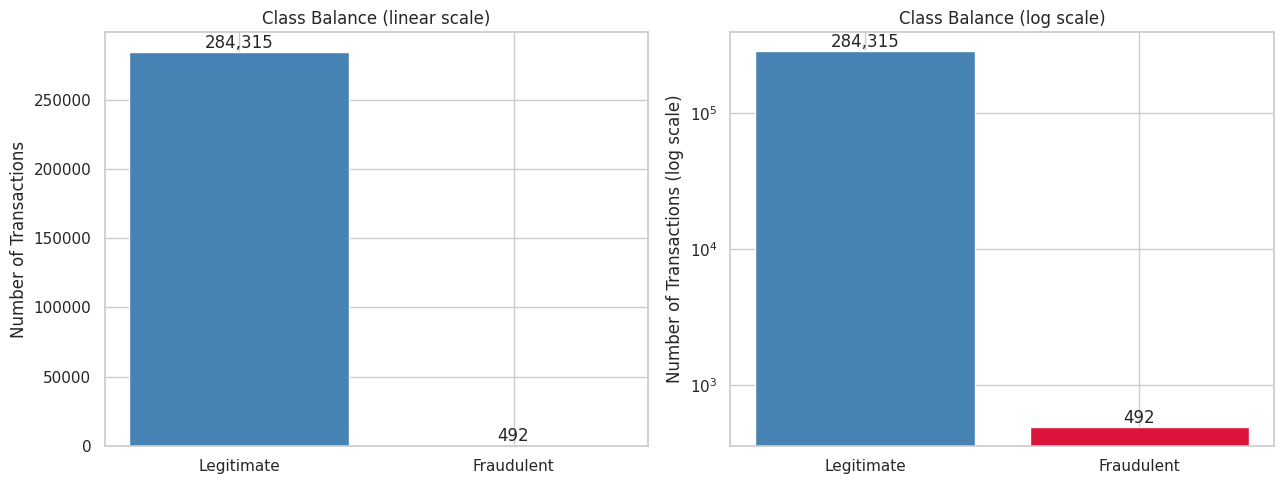

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale: this is what the imbalance really looks like
axes[0].bar(['Legitimate', 'Fraudulent'], class_counts.values, color=['steelblue', 'crimson'])
axes[0].set_ylabel('Number of Transactions')
axes[0].set_title('Class Balance (linear scale)')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

# Log scale: needed to see the fraud bar at all
axes[1].bar(['Legitimate', 'Fraudulent'], class_counts.values, color=['steelblue', 'crimson'])
axes[1].set_yscale('log')
axes[1].set_ylabel('Number of Transactions (log scale)')
axes[1].set_title('Class Balance (log scale)')
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Look at the left chart. The fraud bar is barely a line at the base of the axis. That is not a plotting mistake, it is the actual proportion, and it is the reason the right hand chart uses a logarithmic scale to make the minority class visible at all.

Any model trained on this data will see roughly 578 legitimate transactions for every fraudulent one. Left alone, it will learn that predicting "legitimate" is almost always the safe bet.

## 4. The Accuracy Trap

Before any real model, here is the proof that accuracy cannot be trusted on this dataset.

The model below is deliberately useless. It ignores every feature and always predicts "legitimate".

In [31]:
features = [c for c in df.columns if c != 'Class']

X = df[features]
y = df['Class']

# stratify is essential here. Without it, a random split could easily
# put a wildly different fraud rate in the test set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train), "with", y_train.sum(), "frauds")
print("Testing samples: ", len(X_test), "with", y_test.sum(), "frauds")

Training samples: 227845 with 394 frauds
Testing samples:  56962 with 98 frauds


In [32]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("Accuracy of a model that flags NOTHING as fraud:")
print("  ", round(accuracy_score(y_test, dummy_pred) * 100, 4), "%")
print()
print("Frauds in the test set:", int(y_test.sum()))
print("Frauds this model caught:", int(((dummy_pred == 1) & (y_test == 1)).sum()))
print()
print(classification_report(y_test, dummy_pred, target_names=['Legitimate', 'Fraud'], zero_division=0))

Accuracy of a model that flags NOTHING as fraud:
   99.828 %

Frauds in the test set: 98
Frauds this model caught: 0

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



### Why accuracy is the wrong metric for this dataset

A model that detects **no fraud whatsoever** scores over 99.8 percent accuracy. If accuracy were the reporting metric, this model would look close to perfect, and it would be worth nothing at all to a bank. Every single fraudulent transaction would go through undetected.

The reason is arithmetic rather than anything subtle. Accuracy asks what fraction of all predictions were correct, and when 99.83 percent of transactions are legitimate, simply answering "legitimate" every time is correct 99.83 percent of the time. The metric is dominated by the majority class, so the minority class, which is the entire reason the model exists, contributes almost nothing to the score.

There is a second and more damaging consequence. A model trained without any correction is pulled toward the same behaviour, because predicting the majority class minimises its training loss too. The imbalance does not only distort how the model is measured, it distorts what the model learns.

**The metrics that work instead:**

- **Recall** on the fraud class: of all the real frauds, how many did the model catch? This is usually what a bank cares about most.
- **Precision** on the fraud class: of everything the model flagged, how much was actually fraud? This governs how much time the review team wastes on false alarms.
- **F1**: the harmonic mean of the two, which stays low unless both are respectable.
- **PR AUC** (average precision): summarises the precision and recall tradeoff across all thresholds. Section 8 explains why this is preferable to ROC AUC at this ratio.

## 5. Preprocessing

`V1` through `V28` are already PCA outputs, so they are centred and on comparable scales. `Time` and `Amount` are raw and are not, with `Amount` ranging from 0 to over 25,000. Those two get standardized, and the rest pass through untouched.

In [33]:
scale_columns = ['Time', 'Amount']
passthrough_columns = [c for c in features if c not in scale_columns]

preprocessor = ColumnTransformer(transformers=[
    ('scaled', StandardScaler(), scale_columns),
    ('untouched', 'passthrough', passthrough_columns)
])

print("Columns to standardize:", scale_columns)
print("Columns passed through:", len(passthrough_columns))

Columns to standardize: ['Time', 'Amount']
Columns passed through: 28


## 6. Baseline Model, No Rebalancing

A plain Logistic Regression, trained as if the imbalance were not there. This is the "before" half of the comparison.

In [34]:
baseline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_proba = baseline.predict_proba(X_test)[:, 1]

print("Baseline accuracy:", round(accuracy_score(y_test, baseline_pred), 6))
print()
print(classification_report(y_test, baseline_pred, target_names=['Legitimate', 'Fraud'], digits=4))

Baseline accuracy: 0.999157

              precision    recall  f1-score   support

  Legitimate     0.9994    0.9998    0.9996     56864
       Fraud     0.8289    0.6429    0.7241        98

    accuracy                         0.9992     56962
   macro avg     0.9142    0.8213    0.8619     56962
weighted avg     0.9991    0.9992    0.9991     56962



In [35]:
cm = confusion_matrix(y_test, baseline_pred)

print("Confusion matrix:")
print(cm)
print()
print("Frauds in test set:      ", int(y_test.sum()))
print("Frauds caught:           ", cm[1, 1])
print("Frauds missed:           ", cm[1, 0])
print("False alarms raised:     ", cm[0, 1])

Confusion matrix:
[[56851    13]
 [   35    63]]

Frauds in test set:       98
Frauds caught:            63
Frauds missed:            35
False alarms raised:      13


Note that the baseline is not useless, unlike the dummy model. It catches a meaningful share of frauds, because the PCA features carry real signal. But look at how many frauds it still misses. Those are transactions that went through.

## 7. Three Rebalancing Techniques

### The critical rule about resampling

SMOTE and undersampling must be applied to the **training data only**, never to the test set. This sounds obvious and is very easy to get wrong.

If SMOTE runs before the train/test split, synthetic fraud examples generated from real frauds end up in both halves. The model then gets tested on data derived from what it trained on, and reported recall can look spectacular while the model fails completely in production. This is one of the most common serious mistakes in imbalanced learning writeups.

The protection here is `imblearn`'s own `Pipeline`, used in place of scikit-learn's. It understands resampling steps and applies them **only during fitting**, automatically skipping them at prediction time. The test set never sees a synthetic sample.

### The three approaches

| Technique | What it does | Tradeoff |
|---|---|---|
| `class_weight='balanced'` | Leaves the data alone, and makes minority class errors count more in the loss function. | Cheapest option, no new data, nothing discarded. |
| **SMOTE** | Creates synthetic minority samples by interpolating between real frauds and their nearest neighbours. | Balances without discarding data, but the synthetic points are educated guesses, not real transactions. |
| **Random undersampling** | Throws away majority class rows until the classes match. | Simple and fast, but here it would discard roughly 284,000 legitimate transactions, losing enormous amounts of information. |

In [36]:
# Technique 1: class weighting
weighted = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
weighted.fit(X_train, y_train)
weighted_pred = weighted.predict(X_test)
weighted_proba = weighted.predict_proba(X_test)[:, 1]

print("Class weighted model trained.")

Class weighted model trained.


In [37]:
# Technique 2: SMOTE, applied inside the pipeline so it touches training folds only
smote_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
smote_model.fit(X_train, y_train)
smote_pred = smote_model.predict(X_test)
smote_proba = smote_model.predict_proba(X_test)[:, 1]

print("SMOTE model trained.")

SMOTE model trained.


In [38]:
# How much data did SMOTE actually create?
X_train_processed = preprocessor.fit_transform(X_train)
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X_train_processed, y_train)

print("Training set before SMOTE:", X_train_processed.shape[0], "rows,", int(y_train.sum()), "frauds")
print("Training set after SMOTE: ", X_resampled.shape[0], "rows,", int(y_resampled.sum()), "frauds")
print()
print("Synthetic frauds created:", int(y_resampled.sum() - y_train.sum()))
print()
print("This inflation happens during training only. The test set is untouched.")

Training set before SMOTE: 227845 rows, 394 frauds
Training set after SMOTE:  454902 rows, 227451 frauds

Synthetic frauds created: 227057

This inflation happens during training only. The test set is untouched.


In [39]:
# Technique 3: random undersampling
under_model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
under_model.fit(X_train, y_train)
under_pred = under_model.predict(X_test)
under_proba = under_model.predict_proba(X_test)[:, 1]

X_under, y_under = RandomUnderSampler(random_state=42).fit_resample(X_train_processed, y_train)

print("Training set before undersampling:", X_train_processed.shape[0], "rows")
print("Training set after undersampling: ", X_under.shape[0], "rows")
print()
print("Legitimate transactions discarded:", X_train_processed.shape[0] - X_under.shape[0])

Training set before undersampling: 227845 rows
Training set after undersampling:  788 rows

Legitimate transactions discarded: 227057


That last number is worth pausing on. Undersampling threw away well over 200,000 real transactions in order to balance the classes. It still often works, but it is a blunt instrument.

## 8. Before and After Comparison

All four models on the same metrics. Precision, recall, and F1 are reported for the **fraud** class.

In [40]:
def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_proba),
        'PR AUC': average_precision_score(y_true, y_proba)
    }

results = pd.DataFrame({
    'Baseline (no balancing)': get_metrics(y_test, baseline_pred, baseline_proba),
    'Class weighted': get_metrics(y_test, weighted_pred, weighted_proba),
    'SMOTE': get_metrics(y_test, smote_pred, smote_proba),
    'Undersampling': get_metrics(y_test, under_pred, under_proba)
}).T

print(results.round(4).to_string())

                         Accuracy  Precision  Recall  F1-Score  ROC AUC  PR AUC
Baseline (no balancing)    0.9992     0.8289  0.6429    0.7241   0.9559  0.7432
Class weighted             0.9755     0.0610  0.9184    0.1144   0.9722  0.7159
SMOTE                      0.9742     0.0580  0.9184    0.1092   0.9699  0.7249
Undersampling              0.9603     0.0384  0.9184    0.0738   0.9759  0.6778


In [41]:
# Fraud counts behind those percentages
counts = []
for name, preds in [
    ('Baseline (no balancing)', baseline_pred),
    ('Class weighted', weighted_pred),
    ('SMOTE', smote_pred),
    ('Undersampling', under_pred)
]:
    cm = confusion_matrix(y_test, preds)
    counts.append({
        'Model': name,
        'Frauds Caught': cm[1, 1],
        'Frauds Missed': cm[1, 0],
        'False Alarms': cm[0, 1]
    })

counts_df = pd.DataFrame(counts)
print("Test set contains", int(y_test.sum()), "frauds and", int((y_test == 0).sum()), "legitimate transactions")
print()
print(counts_df.to_string(index=False))

Test set contains 98 frauds and 56864 legitimate transactions

                  Model  Frauds Caught  Frauds Missed  False Alarms
Baseline (no balancing)             63             35            13
         Class weighted             90              8          1386
                  SMOTE             90              8          1461
          Undersampling             90              8          2252


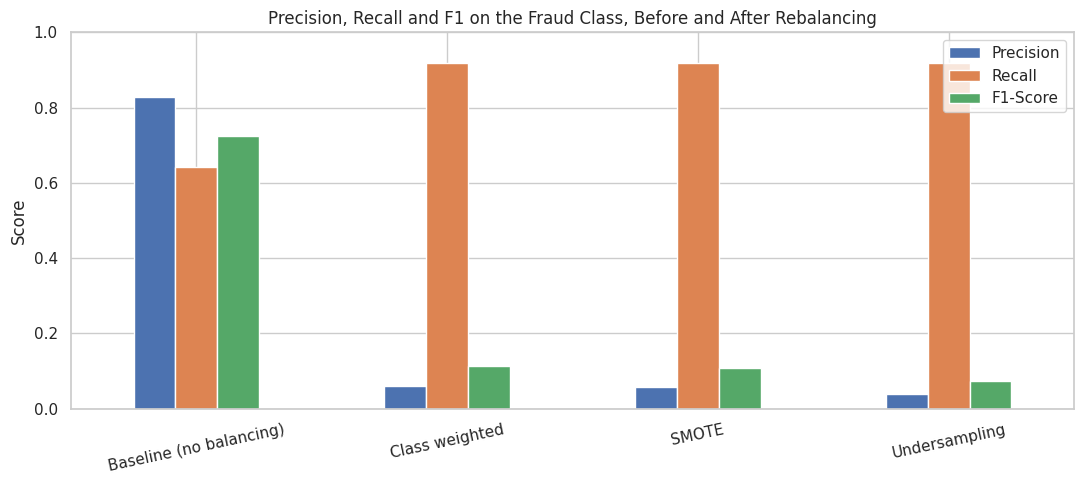

In [42]:
results[['Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(11, 5), rot=12)

plt.ylabel('Score')
plt.title('Precision, Recall and F1 on the Fraud Class, Before and After Rebalancing')
plt.ylim(0, 1)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

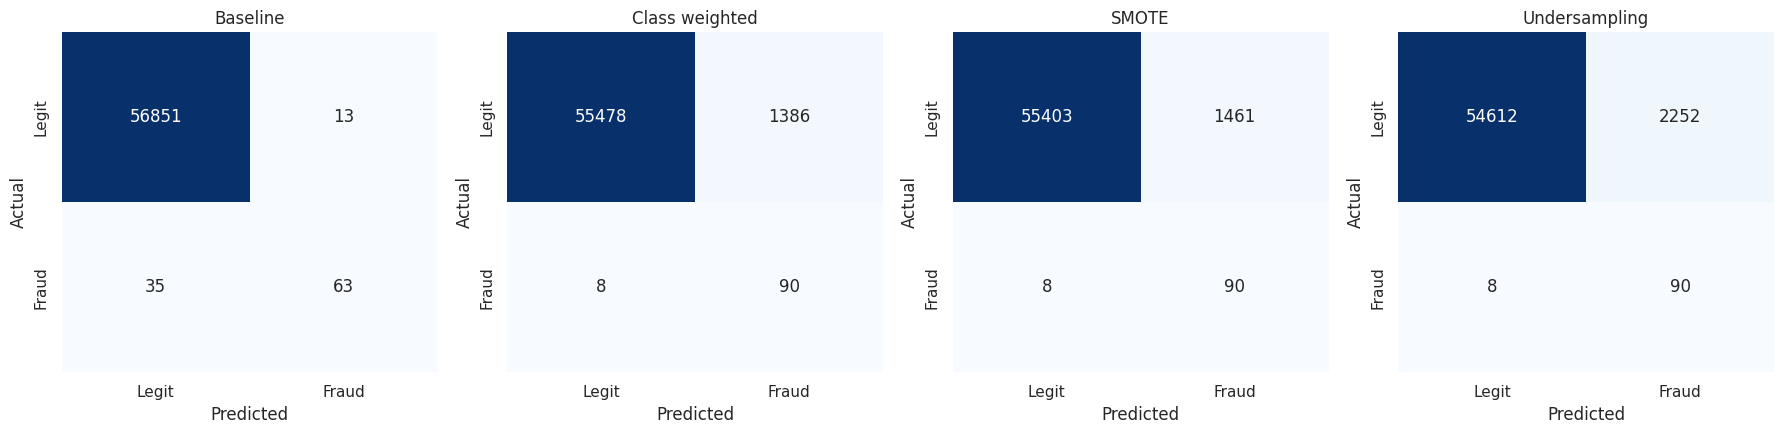

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, preds, title in zip(
    axes,
    [baseline_pred, weighted_pred, smote_pred, under_pred],
    ['Baseline', 'Class weighted', 'SMOTE', 'Undersampling']
):
    sns.heatmap(
        confusion_matrix(y_test, preds),
        annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'], ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Reading the tradeoff

The pattern should be clear from the table. Rebalancing lifts **recall** substantially, meaning far more frauds are caught, and it drops **precision**, meaning far more legitimate transactions are wrongly flagged.

This is not a defect in the technique. It is the same tradeoff seen in Tasks 5 and 6, appearing far more starkly because the imbalance is far more extreme. Rebalancing tells the model that missing a fraud is expensive, and the model responds by flagging more aggressively.

Whether that is a good deal depends entirely on the relative cost of the two mistakes, which is a business question rather than a technical one.

### A result worth not glossing over

Look at the F1 column carefully. **F1 gets dramatically worse after rebalancing**, and the baseline model has the best F1 and the best PR AUC of the four.

That is not a bug, and it does not mean rebalancing failed. It means something more precise: at a fixed 0.5 threshold, rebalancing overcorrects badly on data this skewed. The rebalanced models catch far more frauds, going from 63 to 90 out of 98, but they raise well over a thousand false alarms to do it, and precision collapses to a few percent. F1 punishes that heavily.

The useful conclusion is that **rebalancing and threshold selection are two separate levers, and rebalancing alone is the blunter of the two.** Rebalancing changed where the model draws its line by shifting the training loss. Section 10 shows what happens when the line is chosen deliberately instead, using the same class weighted model and nothing but a different cutoff. The result is far better than either the baseline or the rebalanced model at 0.5.

Reporting only "recall went from 0.64 to 0.92" would be technically true and genuinely misleading, because it hides the thousand extra false alarms that came with it. The fraud count table above exists precisely so that the cost of the improvement is visible alongside the improvement.

## 9. Why ROC AUC Is Also Misleading Here

The comparison table includes both ROC AUC and PR AUC, and the gap between them is instructive.

ROC AUC uses the false positive rate, which divides false alarms by the total number of legitimate transactions. With over 284,000 legitimate transactions in the denominator, even several thousand false alarms barely move that rate. ROC AUC therefore looks reassuringly high even for a model that would flood a review team with noise.

Precision and recall never involve that huge denominator. PR AUC only ever asks about the fraud class, so it stays honest when the negative class is overwhelming. **For heavily imbalanced problems, the precision recall curve is the more informative view.**

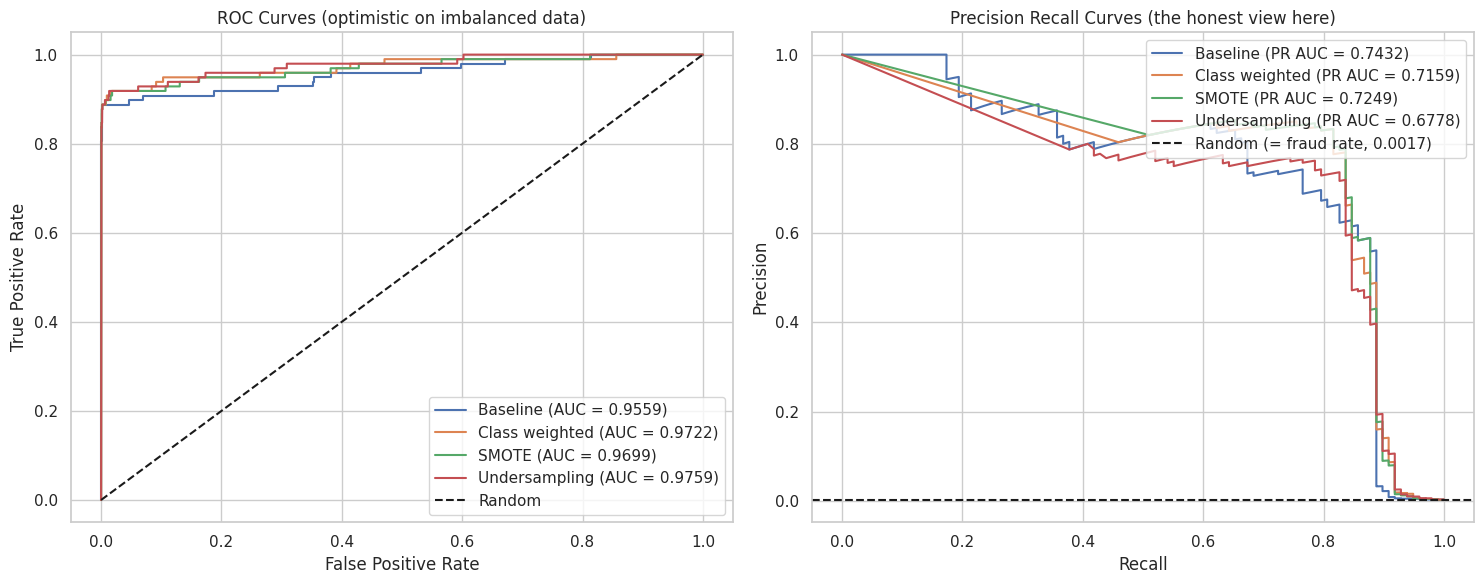

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

model_probas = [
    ('Baseline', baseline_proba),
    ('Class weighted', weighted_proba),
    ('SMOTE', smote_proba),
    ('Undersampling', under_proba)
]

for name, proba in model_probas:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, proba):.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (optimistic on imbalanced data)')
axes[0].legend(loc='lower right')

for name, proba in model_probas:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name} (PR AUC = {average_precision_score(y_test, proba):.4f})')

baseline_rate = y_test.mean()
axes[1].axhline(y=baseline_rate, color='k', linestyle='--',
                label=f'Random (= fraud rate, {baseline_rate:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision Recall Curves (the honest view here)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

Compare the two panels. The ROC curves all hug the top left corner and look close to excellent. The precision recall curves are far more spread out and far less flattering, and they are the ones telling the truth about how these models would behave in a review queue.

## 10. Choosing a Threshold from Business Cost

Every model above used the default cutoff of 0.5, which is an arbitrary convention rather than an optimal choice. Since the model outputs a probability, the threshold can be set deliberately.

Suppose the bank estimates that a missed fraud costs roughly 100 units on average, in refunds and chargebacks, while reviewing a false alarm costs about 2 units in analyst time. Those numbers are illustrative, but the method is real, and this is how thresholds get set in production.

In [45]:
COST_MISSED_FRAUD = 100
COST_FALSE_ALARM = 2

thresholds = np.linspace(0.01, 0.99, 99)
costs = []

for t in thresholds:
    preds_at_t = (weighted_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds_at_t)
    missed = cm_t[1, 0]
    false_alarms = cm_t[0, 1]
    costs.append(missed * COST_MISSED_FRAUD + false_alarms * COST_FALSE_ALARM)

costs = np.array(costs)
best_index = costs.argmin()
best_threshold = thresholds[best_index]

print("Cost assumptions: missed fraud =", COST_MISSED_FRAUD, ", false alarm =", COST_FALSE_ALARM)
print()
print("Cost at the default 0.5 threshold:", int(costs[np.argmin(np.abs(thresholds - 0.5))]))
print("Lowest cost threshold:", round(best_threshold, 2))
print("Cost at that threshold:", int(costs[best_index]))

Cost assumptions: missed fraud = 100 , false alarm = 2

Cost at the default 0.5 threshold: 3572
Lowest cost threshold: 0.97
Cost at that threshold: 1290


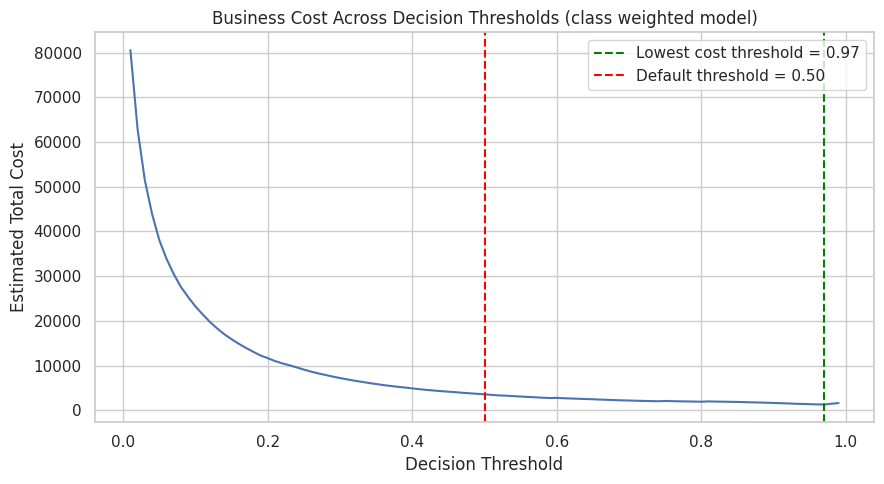

In [46]:
plt.figure(figsize=(9, 5))

plt.plot(thresholds, costs)
plt.axvline(x=best_threshold, color='green', linestyle='--',
            label=f'Lowest cost threshold = {best_threshold:.2f}')
plt.axvline(x=0.5, color='red', linestyle='--', label='Default threshold = 0.50')

plt.xlabel('Decision Threshold')
plt.ylabel('Estimated Total Cost')
plt.title('Business Cost Across Decision Thresholds (class weighted model)')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
tuned_pred = (weighted_proba >= best_threshold).astype(int)
cm_tuned = confusion_matrix(y_test, tuned_pred)

print("At the cost optimal threshold of", round(best_threshold, 2), ":")
print("  Frauds caught:", cm_tuned[1, 1], "out of", int(y_test.sum()))
print("  Frauds missed:", cm_tuned[1, 0])
print("  False alarms: ", cm_tuned[0, 1])
print()
print(classification_report(y_test, tuned_pred, target_names=['Legitimate', 'Fraud'], digits=4))

At the cost optimal threshold of 0.97 :
  Frauds caught: 87 out of 98
  Frauds missed: 11
  False alarms:  95

              precision    recall  f1-score   support

  Legitimate     0.9998    0.9983    0.9991     56864
       Fraud     0.4780    0.8878    0.6214        98

    accuracy                         0.9981     56962
   macro avg     0.7389    0.9430    0.8102     56962
weighted avg     0.9989    0.9981    0.9984     56962



## 11. Final Comparison Table

Ready to copy into the README.

In [48]:
final_table = results.round(4)

print("| Model | Accuracy | Precision | Recall | F1-Score | ROC AUC | PR AUC |")
print("|---|---|---|---|---|---|---|")
for name, row in final_table.iterrows():
    print(f"| {name} | {row['Accuracy']:.4f} | {row['Precision']:.4f} | {row['Recall']:.4f} | "
          f"{row['F1-Score']:.4f} | {row['ROC AUC']:.4f} | {row['PR AUC']:.4f} |")

print()
print("| Model | Frauds Caught | Frauds Missed | False Alarms |")
print("|---|---|---|---|")
for _, row in counts_df.iterrows():
    print(f"| {row['Model']} | {row['Frauds Caught']} | {row['Frauds Missed']} | {row['False Alarms']} |")

| Model | Accuracy | Precision | Recall | F1-Score | ROC AUC | PR AUC |
|---|---|---|---|---|---|---|
| Baseline (no balancing) | 0.9992 | 0.8289 | 0.6429 | 0.7241 | 0.9559 | 0.7432 |
| Class weighted | 0.9755 | 0.0610 | 0.9184 | 0.1144 | 0.9722 | 0.7159 |
| SMOTE | 0.9742 | 0.0580 | 0.9184 | 0.1092 | 0.9699 | 0.7249 |
| Undersampling | 0.9603 | 0.0384 | 0.9184 | 0.0738 | 0.9759 | 0.6778 |

| Model | Frauds Caught | Frauds Missed | False Alarms |
|---|---|---|---|
| Baseline (no balancing) | 63 | 35 | 13 |
| Class weighted | 90 | 8 | 1386 |
| SMOTE | 90 | 8 | 1461 |
| Undersampling | 90 | 8 | 2252 |


## 12. Summary

**What was done**

1. Measured an extreme class imbalance: 492 frauds among 284,807 transactions, about 0.17 percent.
2. Demonstrated the accuracy trap with a model that catches zero frauds and still scores above 99.8 percent.
3. Applied three rebalancing techniques: class weighting, SMOTE, and random undersampling.
4. Compared precision, recall, and F1 before and after, with fraud counts alongside the percentages.
5. Showed why ROC AUC flatters models on this data and why PR AUC is the better summary.
6. Selected a decision threshold from explicit cost assumptions rather than accepting the default.

**Key conclusions**

- Accuracy is actively misleading at this ratio. It is dominated by the majority class and says almost nothing about the only class that matters.
- Rebalancing buys recall and pays for it in precision. The right point on that curve is a business decision, not a technical default.
- Resampling belongs inside the pipeline. Applying SMOTE before the split leaks synthetic data into the test set and produces impressive numbers that mean nothing.
- Class weighting is often the sensible first choice. It costs nothing, discards nothing, invents nothing, and on this dataset performs comparably to the more elaborate options.

**Limitations**

- The test set contains only about 98 frauds, so recall moves in steps of roughly one percent and small differences between models are not meaningful.
- Only Logistic Regression was used, to keep the comparison focused on the rebalancing techniques. Ensembles from Task 8 would likely perform better.
- The cost figures in Section 10 are illustrative. Real deployment would use the bank's actual chargeback and review costs.
- SMOTE interpolates between existing frauds, so it can only extend patterns already present. It cannot anticipate a genuinely new fraud technique.